# AML Dataset Analysis

This notebook analyses three synthetic Anti-Money Laundering (AML) datasets:

| # | Dataset | Source | Notes |
|---|---|---|---|
| 1 | **IBM AMLSim** (HI-Small) | [Kaggle](https://www.kaggle.com/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml) | Multi-agent simulator |
| 2 | **AMLNet** *(AMLGentex-equivalent)* | [Zenodo](https://zenodo.org/records/21237971) | ~1.09M txns, free download |
| 3 | **SAML-D** | [Kaggle](https://www.kaggle.com/datasets/berkanoztas/synthetic-transaction-monitoring-dataset-aml) | ~9.5M txns, 28 typologies |

For each dataset we:
1. Load the data via the unified `DatasetFactory`
2. Print a feature table (column name, type, description, possible values)
3. Show summary statistics and feature distributions
4. Build the transaction graph (accounts = nodes, transactions = edges)
5. Visualise 3 example transaction subgraphs (fast — no full graph needed)  
   - 🔴 **Red** edges / nodes → fraudulent (money-laundering) transactions  
   - 🔵 **Blue** edges / nodes → normal transactions

---

## File placement

| Dataset | Path | How to get |
|---|---|---|
| IBM AMLSim | `Code/data/ibm_amlsim/HI-Small_Trans.csv` | Download from Kaggle (requires account) |
| AMLNet | `Code/data/amlgentex/transactions.csv` | **Auto-downloaded from Zenodo** |
| SAML-D | `Code/data/saml_d/SAML-D.csv` | Download from Kaggle (requires account) |

Cells for missing datasets will print a clear error with the download URL.

## 0  Setup

In [1]:
import sys
import os

# Make sure the Code directory is on the path so Python can find our modules.
CODE_DIR = os.path.dirname(os.path.abspath("__file__"))
if CODE_DIR not in sys.path:
    sys.path.insert(0, CODE_DIR)

import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

from dataset_factory import DatasetFactory

%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f9fa",
    "font.family": "sans-serif",
})

print("Available datasets:", DatasetFactory.available_datasets())

Available datasets: ['ibm_amlsim', 'amlgentex', 'saml_d']


---
## 1  IBM AMLSim (HI-Small)

> **Source**: [Kaggle – IBM Transactions for AML](https://www.kaggle.com/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml)  
> **Generator**: IBM AMLSim multi-agent simulator ([GitHub](https://github.com/IBM/AMLSim))  
> **Schema**: 11 columns — accounts as nodes, transactions as directed edges with currency and payment-format metadata.

⚠️ *Place `HI-Small_Trans.csv` in `Code/data/ibm_amlsim/` before running this section.*

### 1.1  Load

In [2]:
try:
    ibm_loader = DatasetFactory.get_loader("ibm_amlsim")
    ibm_loader.load()
    ibm_loader.summary()
    ibm_df = ibm_loader.get_transactions()
    ibm_ok = True
except FileNotFoundError as e:
    print(f"[SKIP] {e}")
    ibm_ok = False

[SKIP] IBM AMLSim CSV not found at:
  c:\Users\marti\Desktop\Magistrale\Tesi v2\Code\data\ibm_amlsim\HI-Small_Trans.csv
Download from: https://www.kaggle.com/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml


In [3]:
if ibm_ok:
    ibm_df.head(5)

### 1.2  Features

In [4]:
if ibm_ok:
    ibm_loader.print_features()

In [5]:
if ibm_ok:
    features_ibm = ibm_loader.get_features()
    pd.DataFrame([
        {
            "Column": col,
            "Type": meta["dtype"],
            "Description": meta["description"],
            "Possible Values": str(meta["possible_values"]) if meta["possible_values"] else "continuous",
        }
        for col, meta in features_ibm.items()
    ]).set_index("Column")

### 1.3  Distributions

In [6]:
if ibm_ok:
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    fig.suptitle("IBM AMLSim – Transaction Subgraph Example", fontsize=13, fontweight="bold")
    
    ibm_loader.plot_subgraph(seed_node=None, max_nodes=50, ax=ax, title="Random Fraud Seed")
    
    plt.tight_layout()
    plt.show()

### 1.4  Build the transaction graph

Uses `nx.from_pandas_edgelist` — much faster than row-by-row iteration.

In [7]:
if ibm_ok:
    ibm_graph = ibm_loader.build_graph()
    print(f"Nodes (accounts)    : {ibm_graph.number_of_nodes():,}")
    print(f"Edges (transactions): {ibm_graph.number_of_edges():,}")

### 1.5  Subgraph examples

Each panel shows a **small (~15-node) BFS subgraph** centred on a fraud-participating account.  
The subgraph is built directly from the DataFrame (no full-graph traversal) so it renders in seconds.  
🔴 **Red** edges = fraudulent &nbsp;&nbsp; 🔵 **Blue** edges = normal

In [8]:
if ibm_ok:
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    fig.suptitle("IBM AMLSim – Transaction Subgraph Example", fontsize=13, fontweight="bold")
    
    ibm_loader.plot_subgraph(seed_node=None, max_nodes=50, ax=ax, title="Random Fraud Seed")
    
    plt.tight_layout()
    plt.show()

---
## 2  AMLNet (AMLGentex-equivalent)

> **Source**: [Zenodo – AMLNet v2.0](https://zenodo.org/records/21237971)  (CC BY-NC 4.0, no account needed)  
> **Paper**: *AMLNet: A Knowledge-Guided Synthetic Benchmark for Machine Learning Evaluation in Anti-Money Laundering*  

AMLNet is a state-of-the-art synthetic AML benchmark generated by a
multi-agent knowledge-guided framework — the closest freely available
equivalent to the AMLGentex framework.  It contains ~1.09 M transactions
over a 195-day simulation, with typology labels (`structuring`, `layering`,
`integration`) and rich temporal metadata.

✅ *This file was downloaded automatically from Zenodo into `Code/data/amlgentex/`.*

### 2.1  Load

In [9]:
try:
    amlg_loader = DatasetFactory.get_loader("amlgentex")
    amlg_loader.load()
    amlg_loader.summary()
    amlg_df = amlg_loader.get_transactions()
    amlg_ok = True
except FileNotFoundError as e:
    print(f"[SKIP] {e}")
    amlg_ok = False

Loading AMLNet (AMLGentex-equivalent) from: c:\Users\marti\Desktop\Magistrale\Tesi v2\Code\data\amlgentex\transactions.csv
  Loaded 1,090,000 rows.
  Dataset : AMLGentexLoader
  Rows    : 1,090,000
  Columns : 15
  Fraud   : 1,411  (0.1294 %)



In [10]:
if amlg_ok:
    print(amlg_df.head(5))

   step   type      amount    category nameOrig nameDest  oldbalanceOrg  \
0     0   BPAY  121.231873        Food    C4638    C1811  332687.934283   
1     0   OSKO   98.099062       Other    C5536    C6852  455880.908413   
2     0  DEBIT   93.861773  Healthcare     C450    C4987  266729.197862   
3     0   BPAY  156.833185       Other     C503      C99  497635.915154   
4     0  DEBIT   63.286125   Transport    C4791    C7610  350189.092731   

   newbalanceOrig  isFraud  isMoneyLaundering laundering_typology  hour  \
0   332566.702410        0                  0              normal    17   
1   455782.809350        0                  0              normal    18   
2   266635.336089        0                  0              normal    18   
3   497479.081970        0                  0              normal    18   
4   350125.806606        0                  0              normal    19   

   day_of_week  day_of_month  month  
0            0            13     10  
1            0        

### 2.2  Features

In [11]:
if amlg_ok:
    amlg_loader.print_features()


Column                Type         Description
--------------------------------------------------------------------------------
step                  int64        Sequential simulation step (transaction index)
type                  object       Transaction instrument / type  (e.g. ['BPAY', 'OSKO', 'DEBIT', 'TRANSFER', 'EFTPOS', 'CASH_OUT', 'NPP', 'PAYMENT'])
amount                float64      Transaction amount in Australian dollars (AUD)
category              object       Spending/transaction category  (e.g. ['Food', 'Other', 'Healthcare', 'Transport', 'Education', 'Housing', 'Recreation', 'Utilities'])
nameOrig              object       Originating account or customer identifier (node)
nameDest              object       Destination account, customer, or merchant identifier (node)
oldbalanceOrg         float64      Originating account balance before the transaction
newbalanceOrig        float64      Originating account balance after the transaction
isFraud               int64        

In [12]:
if amlg_ok:
    features_amlg = amlg_loader.get_features()
    pd.DataFrame([
        {
            "Column": col,
            "Type": meta["dtype"],
            "Description": meta["description"],
            "Possible Values": str(meta["possible_values"]) if meta["possible_values"] else "continuous",
        }
        for col, meta in features_amlg.items()
    ]).set_index("Column")

### 2.3  Distributions

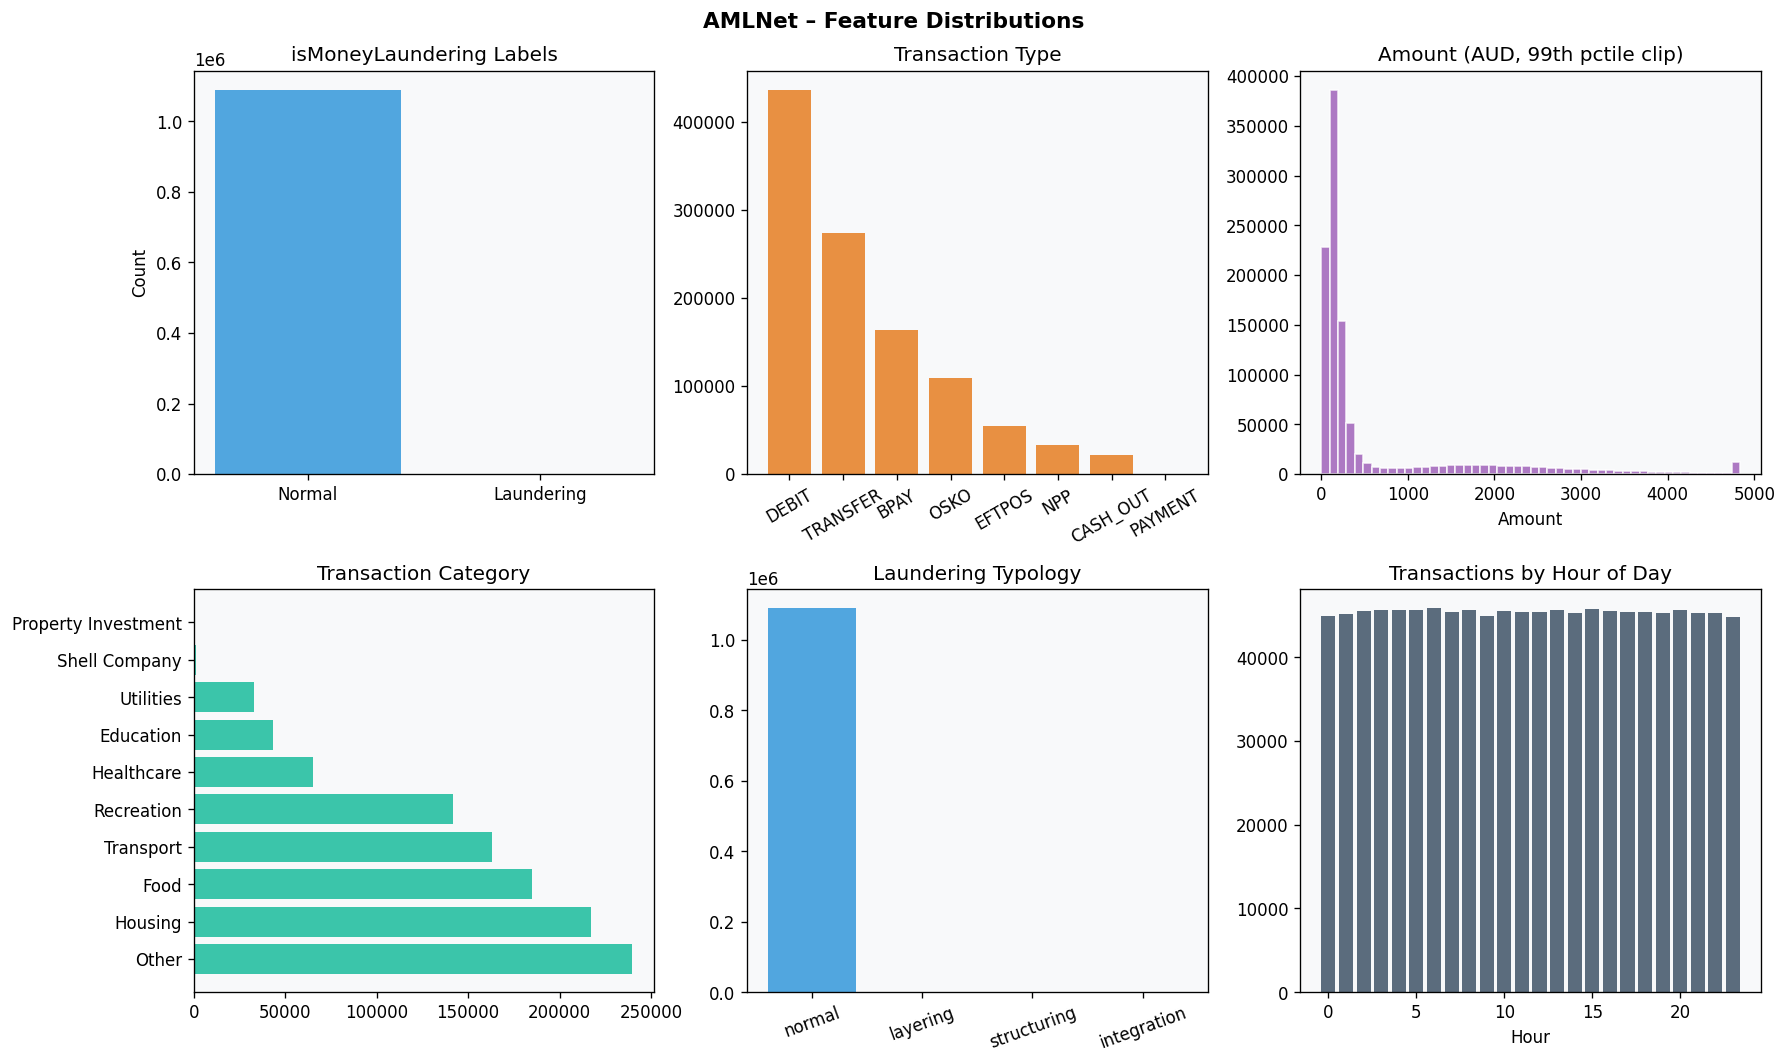

In [13]:
if amlg_ok:
    fig, axes = plt.subplots(2, 3, figsize=(15, 9))
    fig.suptitle("AMLNet – Feature Distributions", fontsize=13, fontweight="bold")

    # Row 1
    # Fraud ratio (isMoneyLaundering)
    counts = amlg_df["isMoneyLaundering"].value_counts()
    axes[0,0].bar(["Normal", "Laundering"], [counts.get(0, 0), counts.get(1, 0)],
                  color=["#3498db", "#e74c3c"], alpha=0.85)
    axes[0,0].set_title("isMoneyLaundering Labels")
    axes[0,0].set_ylabel("Count")

    # Transaction type
    type_counts = amlg_df["type"].value_counts()
    axes[0,1].bar(type_counts.index, type_counts.values, color="#e67e22", alpha=0.85)
    axes[0,1].set_title("Transaction Type")
    axes[0,1].tick_params(axis="x", rotation=30)

    # Amount distribution
    axes[0,2].hist(amlg_df["amount"].clip(upper=amlg_df["amount"].quantile(0.99)),
                   bins=50, color="#9b59b6", alpha=0.8, edgecolor="white")
    axes[0,2].set_title("Amount (AUD, 99th pctile clip)")
    axes[0,2].set_xlabel("Amount")

    # Row 2
    # Category
    cat_counts = amlg_df["category"].value_counts().head(10)
    axes[1,0].barh(cat_counts.index, cat_counts.values, color="#1abc9c", alpha=0.85)
    axes[1,0].set_title("Transaction Category")

    # Laundering typology breakdown
    typ_counts = amlg_df["laundering_typology"].value_counts()
    axes[1,1].bar(typ_counts.index, typ_counts.values, color=["#3498db","#e74c3c","#f39c12","#8e44ad"], alpha=0.85)
    axes[1,1].set_title("Laundering Typology")
    axes[1,1].tick_params(axis="x", rotation=20)

    # Transactions by hour
    hour_counts = amlg_df["hour"].value_counts().sort_index()
    axes[1,2].bar(hour_counts.index, hour_counts.values, color="#34495e", alpha=0.8)
    axes[1,2].set_title("Transactions by Hour of Day")
    axes[1,2].set_xlabel("Hour")

    plt.tight_layout()
    plt.show()

### 2.4  Build the transaction graph

Uses `nx.from_pandas_edgelist` — much faster than row-by-row iteration.

In [14]:
if amlg_ok:
    amlg_graph = amlg_loader.build_graph()
    print(f"Nodes (accounts)    : {amlg_graph.number_of_nodes():,}")
    print(f"Edges (transactions): {amlg_graph.number_of_edges():,}")

Nodes (accounts)    : 11,000
Edges (transactions): 364,773


### 2.5  Subgraph examples

Each panel shows a **small (~15-node) BFS subgraph** centred on a fraud-participating account.  
The subgraph is built directly from the DataFrame (no full-graph traversal) so it renders in seconds.  
🔴 **Red** edges = fraudulent &nbsp;&nbsp; 🔵 **Blue** edges = normal

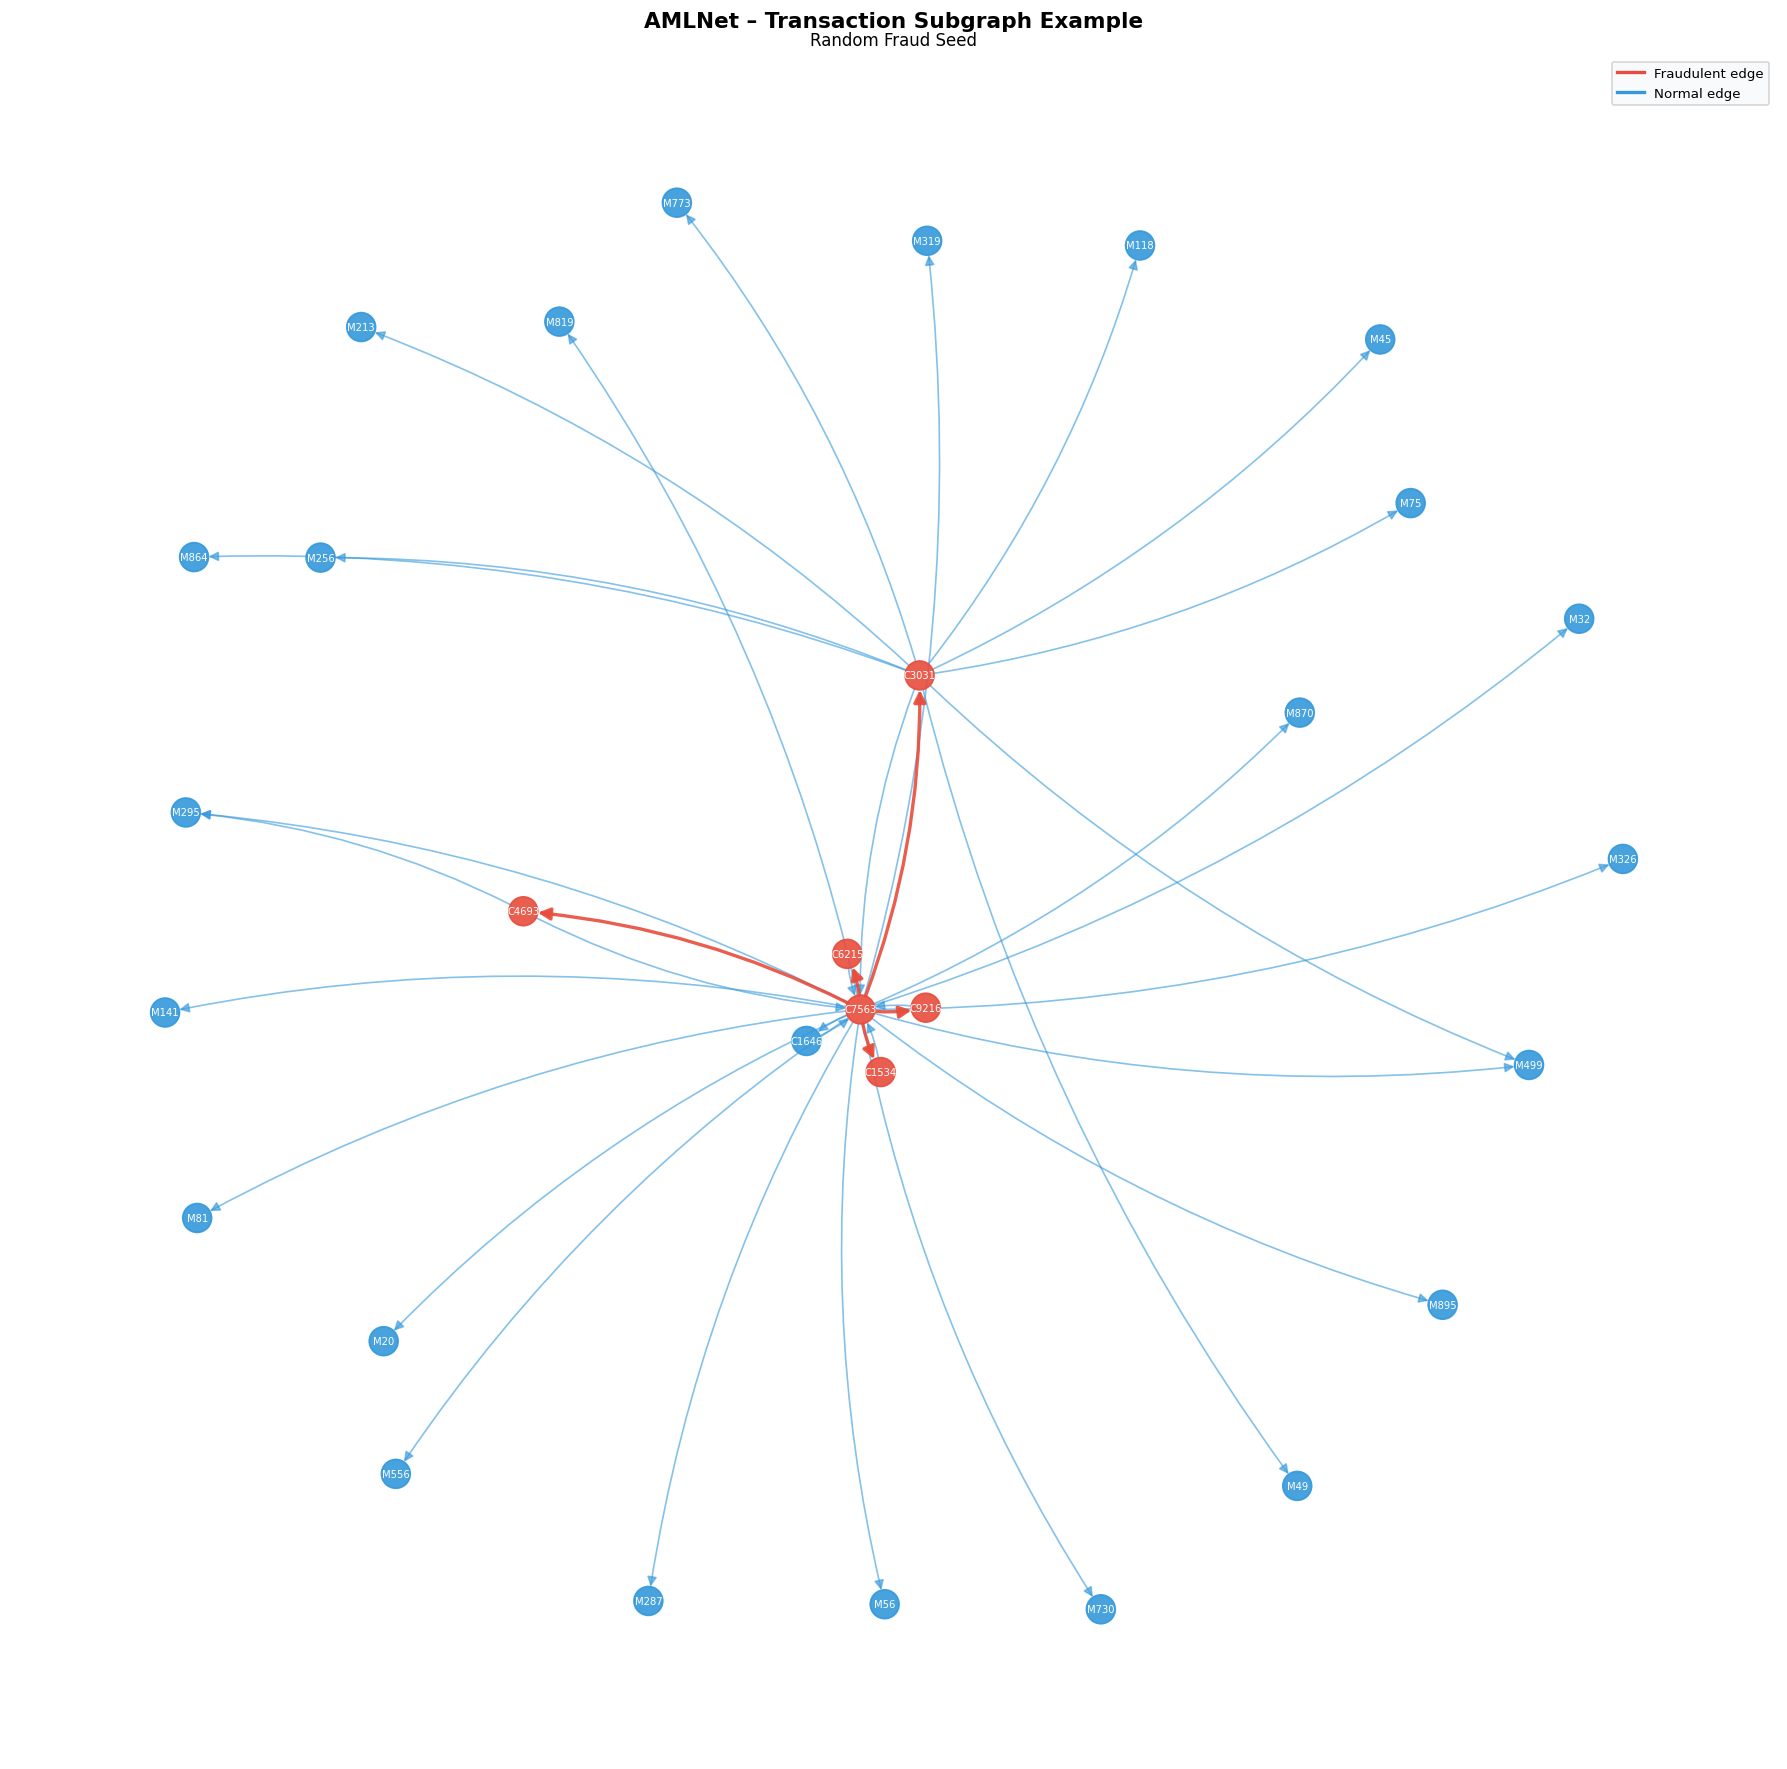

In [36]:
if amlg_ok:
    # plot_subgraph uses fast DataFrame BFS – no full graph needed.
    fig, ax = plt.subplots(1, 1, figsize=(15, 15))
    fig.suptitle("AMLNet – Transaction Subgraph Example", fontsize=13, fontweight="bold")
    
    # We pass seed_node=None to let it randomly pick a fraudulent node, 
    # and max_nodes to bound the subgraph size.
    amlg_loader.plot_subgraph(seed_node=50, max_nodes=30, ax=ax, title="Random Fraud Seed")
    
    plt.tight_layout()
    plt.show()

---
## 3  SAML-D

> **Source**: [Kaggle – Synthetic Transaction Monitoring Dataset (SAML-D)](https://www.kaggle.com/datasets/berkanoztas/synthetic-transaction-monitoring-dataset-aml)  
> **Paper**: Bournemouth University  

SAML-D contains ~9.5 M transactions across **28 typologies** (11 normal + 17 suspicious).
Fraudulent transactions represent ~0.10% of the data.
The file is ~996 MB; we read the first 500,000 rows for exploration.  
Remove `nrows` to analyse the full dataset.

⚠️ *Place `SAML-D.csv` in `Code/data/saml_d/` before running this section.*

### 3.1  Load

In [16]:
try:
    saml_loader = DatasetFactory.get_loader("saml_d", nrows=500_000)
    saml_loader.load()
    saml_loader.summary()
    saml_df = saml_loader.get_transactions()
    saml_ok = True
except FileNotFoundError as e:
    print(f"[SKIP] {e}")
    saml_ok = False

[SKIP] SAML-D CSV not found at:
  c:\Users\marti\Desktop\Magistrale\Tesi v2\Code\data\saml_d\SAML-D.csv
Download from: https://www.kaggle.com/datasets/berkanoztas/synthetic-transaction-monitoring-dataset-aml


In [17]:
if saml_ok:
    saml_df.head(5)

### 3.2  Features

In [18]:
if saml_ok:
    saml_loader.print_features()

In [19]:
if saml_ok:
    features_saml = saml_loader.get_features()
    pd.DataFrame([
        {
            "Column": col,
            "Type": meta["dtype"],
            "Description": meta["description"],
            "Possible Values": str(meta["possible_values"]) if meta["possible_values"] else "continuous",
        }
        for col, meta in features_saml.items()
    ]).set_index("Column")

### 3.3  Distributions

In [20]:
if saml_ok:
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    fig.suptitle("SAML-D – Transaction Subgraph Example", fontsize=13, fontweight="bold")
    
    saml_loader.plot_subgraph(seed_node=None, max_nodes=50, ax=ax, title="Random Fraud Seed")
    
    plt.tight_layout()
    plt.show()

### 3.4  Build the transaction graph

Uses `nx.from_pandas_edgelist` — much faster than row-by-row iteration.

In [21]:
if saml_ok:
    saml_graph = saml_loader.build_graph()
    print(f"Nodes (accounts)    : {saml_graph.number_of_nodes():,}")
    print(f"Edges (transactions): {saml_graph.number_of_edges():,}")

### 3.5  Subgraph examples

Each panel shows a **small (~15-node) BFS subgraph** centred on a fraud-participating account.  
The subgraph is built directly from the DataFrame (no full-graph traversal) so it renders in seconds.  
🔴 **Red** edges = fraudulent &nbsp;&nbsp; 🔵 **Blue** edges = normal

In [22]:
if saml_ok:
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    fig.suptitle("SAML-D – Transaction Subgraph Example", fontsize=13, fontweight="bold")
    
    saml_loader.plot_subgraph(seed_node=None, max_nodes=50, ax=ax, title="Random Fraud Seed")
    
    plt.tight_layout()
    plt.show()

---
## 4  Cross-Dataset Comparison

In [23]:
def dataset_stats(loader, name, ok):
    if not ok:
        return {"Dataset": name, "Status": "⚠️ file not found",
                "Rows": "—", "Columns": "—", "Fraud count": "—",
                "Fraud %": "—", "Nodes": "—", "Edges": "—"}
    df = loader.get_transactions()
    fraud_col = loader._fraud_column()
    n = len(df)
    n_fraud = int(df[fraud_col].sum())
    g = loader._graph
    return {
        "Dataset": name,
        "Status": "✅ loaded",
        "Rows": f"{n:,}",
        "Columns": len(df.columns),
        "Fraud count": f"{n_fraud:,}",
        "Fraud %": f"{100 * n_fraud / n:.4f}%",
        "Nodes": f"{g.number_of_nodes():,}" if g else "—",
        "Edges": f"{g.number_of_edges():,}" if g else "—",
    }

comparison = pd.DataFrame([
    dataset_stats(ibm_loader if ibm_ok else None, "IBM AMLSim (HI-Small)", ibm_ok),
    dataset_stats(amlg_loader if amlg_ok else None, "AMLNet (AMLGentex-equiv.)", amlg_ok),
    dataset_stats(saml_loader if saml_ok else None, "SAML-D (first 500k rows)", saml_ok),
])
comparison.set_index("Dataset")

,Status,Rows,Columns,Fraud count,Fraud %,Nodes,Edges
Dataset,,,,,,,
IBM AMLSim (HI-Small),⚠️ file not found,—,—,—,—,—,—
AMLNet (AMLGentex-equiv.),✅ loaded,"1,090,000",15,"1,411",0.1294%,"11,000","364,773"
SAML-D (first 500k rows),⚠️ file not found,—,—,—,—,—,—
